# Coincidence plots

In [1]:
import os
import sys
import glob
import pickle

path = os.path.abspath("")
splitted = path.split(os.sep)
user_independent = os.path.join(
    splitted[0] + os.sep, splitted[1], splitted[2], splitted[3]
)
src_path = os.path.join(user_independent, "GitHub", "Photoswitching")
sys.path.append(src_path)

import src.blinking as bl
import src.distributions as dist
import src.emissions as em
import src.fcs as fcs_p
import src.figure as fi
import src.fluorophores as fl
import src.formulas as fo
import src.miscellaneous as mi
import src.network as net
import src.simulation as si
import src.prediction as pr
import src.analysis as an
import src.transitions as tr
import src.routines as ro

import numpy as np
import pandas as pd

%load_ext autoreload
%autoreload 2

import warnings


def custom_warning_format(msg, category, filename, lineno, line=None):
    if line is None:
        import linecache

        line = linecache.getline(filename, lineno)
    return f"WARNING for line: {line} {msg} \n"


warnings.formatwarning = custom_warning_format

## General information
If the bin_width is too large, the bunching/antibunching information gets lost. \
If tau_max is too large, only very few photon pairs contribute to the bin. I.e., the number of contributing pairs gets smaller the further away from 0. One can adjust for this by normalizing using T (the maximum time) and the bins as hist / (T-abs(bins)). This corrects for finite window effects.

# Poisson case

In [243]:
intervals = np.random.exponential(scale=1e-5, size=10000)
times = np.cumsum(intervals)
np.max(times)

np.float64(0.09964809648338009)

array([[<Axes: xlabel='x', ylabel='y'>]], dtype=object)

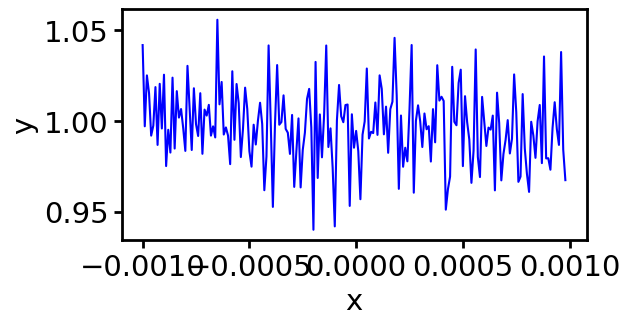

In [244]:
hist, bins = fcs_p.coincidence(times, tau_max=1e-3, bin_width=1e-5)
fi.universal_figure(type_='line', data=[bins[:-2], hist])

# Bunched case
artificially bunched, can exceed 2 on the y axis

array([[<Axes: xlabel='x', ylabel='y'>]], dtype=object)

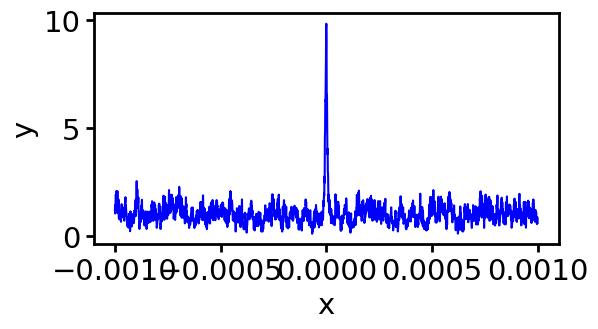

In [245]:
times = []
t = 0.0
duration = 1e-2
n_photons = 20000
while t < duration and len(times) < n_photons:
    burst_size = np.random.poisson(10)  # size of each burst
    burst_intervals = np.random.exponential(scale=1e-6, size=burst_size)
    for dt in burst_intervals:
        t += dt
        times.append(t)
    t += np.random.exponential(scale=1e-4)  # pause between bursts

times = np.array(times)

hist, bins = fcs_p.coincidence(times, tau_max=1e-3, bin_width=1e-6)
fi.universal_figure(type_='line', data=[bins[:-2], hist])

# Antibunched case

array([[<Axes: xlabel='x', ylabel='y'>]], dtype=object)

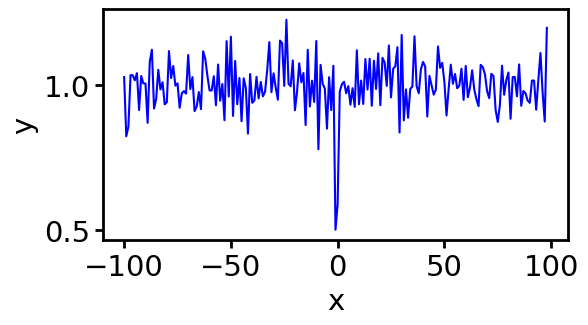

In [247]:
rng = np.random.default_rng(0)
fluorescence_lifetimes = rng.exponential(scale=1, size=1000)
s0_lifetimes = rng.exponential(scale=1, size=1000)
times_of_cycle = fluorescence_lifetimes + s0_lifetimes
times = np.cumsum(times_of_cycle)

hist, bins = fcs_p.coincidence(times, tau_max=1e2, bin_width=1e0)
fi.universal_figure(type_='line', data=[bins[:-2], hist])

# Simulations

In [248]:
def prepare_transition_set_ofret(number_fluorophores, distance):
    fluorophores = fl.construct_fluorophores(
    name="cy5_dna", distance=distance, count=number_fluorophores, shape="square"
    )
    fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)

    transitions = fluorophore_system.load_transitions(
    summarize=True,
    irradiance=2.5,
    wavelength=640,
    bleaching=False,
    energy_transfer=True,
    dstorm=True,
    dstorm_parameters={'reducing_agent':'mea',
    'concentration':100,
    'ph':7.5},
    energy_transfer_parameters={'overwrite': {'off': [1, 0.0001]}, 
                                'exclude': ['s0']}
    )
    transition_set = tr.TransitionSet(transitions, fluorophore_system)
    transition_set.finalize()

    return transition_set

# Simulation continuous

### Only fluorescence and excitation
1 fluorophore. shows antibunching dip at x = 0

array([[<Axes: xlabel='x', ylabel='y'>]], dtype=object)

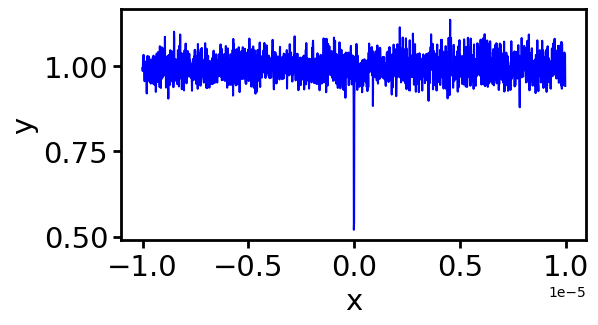

In [270]:
transition_set = prepare_transition_set_ofret(1, 1)
transition_set = transition_set.filter_by_identity(np.arange(2, 11))
transition_set.finalize()

simu = si.Simulation(transition_set)
simu.run(size=1e5)
times = simu.time_series[2::2]

hist, bins = fcs_p.coincidence(times, tau_max=1e-5, bin_width=1e-8)
fi.universal_figure(type_='line', data=[bins[:-2], hist])

### With dSTORM

In [283]:
transition_set = prepare_transition_set_ofret(1, 1)
transition_set.finalize()

simu = si.Simulation(transition_set)
simu.run(size=2e6)
emis = em.Emissions(frame_time='1ms', bandpass=[665, 731], seed=rng)
emis.extract(simu)
times = emis.event_time_points

WARNING for line:                 warnings.warn(
 Floating point precision error warning:
 The higher limit of smallest increment with a probability of 1.00e-03 is 1.69e-12.
 This was estimated using the highest possible rate which occurs for example in state combination [1].
 Everything drawn below this number will be rounded to zero starting somewhere between 1.00e+03 - 1.00e+04. 


This is a blinking fluorophore. Coincidence plots compare the correlation to the expected correlation if the photon source is Poisson with a certain average rate. The blinking fluorophore has long times with no emission, hence the average is much lower than in a coherent photon source. Thats why the y axis may exceed 2 by far. There will be bunching on some time scales (ON periods) and antibunching on very small time scales (S0 lifetime).

#### zoomed out

array([[<Axes: xlabel='x', ylabel='y'>]], dtype=object)

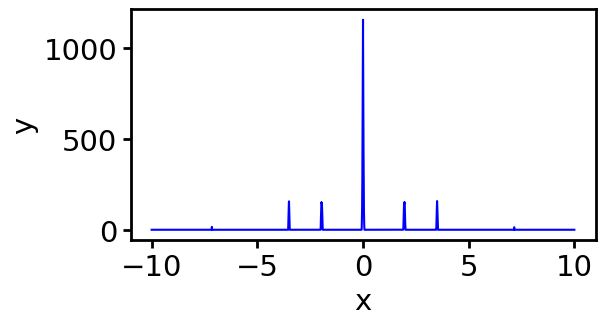

In [284]:
hist, bins = fcs_p.coincidence(times, tau_max=1e1, bin_width=1e-3)
fi.universal_figure(type_='line', data=[bins[:-2], hist])

#### zoomed in 1 of 2

array([[<Axes: xlabel='x', ylabel='y'>]], dtype=object)

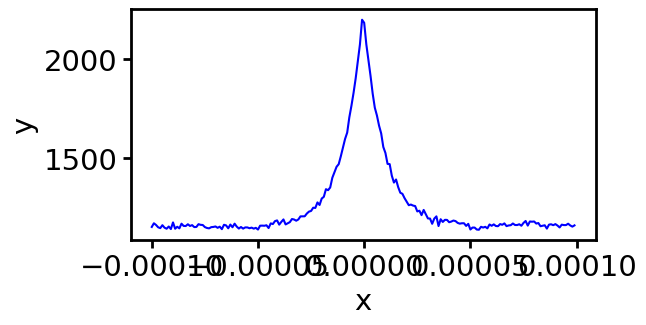

In [286]:
hist, bins = fcs_p.coincidence(times, tau_max=1e-4, bin_width=1e-6)
fi.universal_figure(type_='line', data=[bins[:-2], hist])

#### zoomed in 2 of 2

array([[<Axes: xlabel='x', ylabel='y'>]], dtype=object)

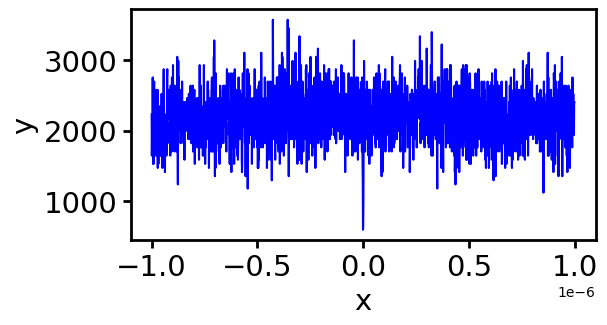

In [288]:
hist, bins = fcs_p.coincidence(times, tau_max=1e-6, bin_width=1e-9)
fi.universal_figure(type_='line', data=[bins[:-2], hist])

# Simulation pulsed

#### Only fluorescence and excitation

In [299]:
transition_set = prepare_transition_set_ofret(1, 3)
transition_set = transition_set.filter_by_identity(np.arange(2, 11))
transition_set.finalize()
rng = np.random.default_rng(42)
emis = em.Emissions(frame_time='1ms', bandpass=[665, 731], seed=rng)
Da, D, lifetimes_all = \
    emis.tcspc(transition_set, number_pulses=1e8, excitation_rates={'cy5_dna': 3.75e9},
               time_between_pulses=12.5e-9, store_time_points=True)
times = emis.event_time_points

WARNING for line:     warnings.warn(
 the last frame (of index 1.25) has 0.00e+00 times the pulses of other frames. 


array([[<Axes: xlabel='x', ylabel='y'>]], dtype=object)

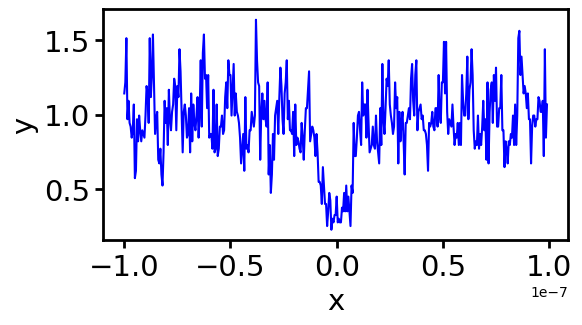

In [303]:
hist, bins = fcs_p.coincidence(times[:200000], tau_max=1e-7, bin_width=5e-10)
fi.universal_figure(type_='line', data=[bins[:-2], hist])

#### With dSTORM

In [306]:
transition_set = prepare_transition_set_ofret(1, 3)
transition_set.finalize()
rng = np.random.default_rng(42)
emis = em.Emissions(frame_time='1ms', bandpass=[665, 731], seed=rng)
Da, D, lifetimes_all = \
    emis.tcspc(transition_set, number_pulses=1e10, excitation_rates={'cy5_dna': 3.75e9},
               time_between_pulses=12.5e-9, store_time_points=True)
times = emis.event_time_points

WARNING for line:     warnings.warn(
 the last frame (of index 125.0) has 0.00e+00 times the pulses of other frames. 


array([[<Axes: xlabel='x', ylabel='y'>]], dtype=object)

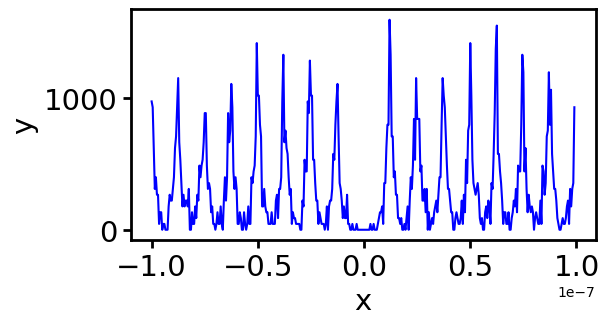

In [307]:
hist, bins = fcs_p.coincidence(times[:200000], tau_max=1e-7, bin_width=5e-10)
fi.universal_figure(type_='line', data=[bins[:-2], hist])

##### Normalized to the peak height

array([[<Axes: xlabel='x', ylabel='y'>]], dtype=object)

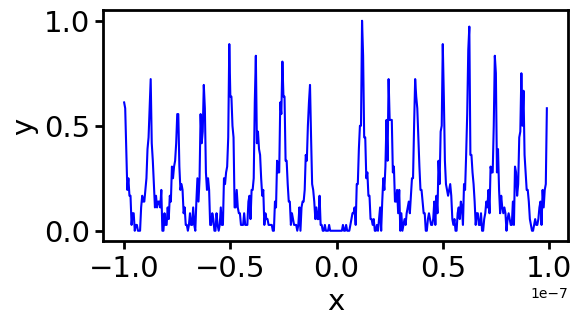

In [308]:
hist, bins = fcs_p.coincidence(times[:200000], tau_max=1e-7, bin_width=5e-10)
hist = hist / np.max(hist)
fi.universal_figure(type_='line', data=[bins[:-2], hist])